## Branch Axis Convention

```
                 z (up, crown)
                 |
<----BRANCH----- . â†’ y (toward joint)
                 |
                 v
                 x (down)
```

- **Pitch** = rotation about y-axis (branch sag): accel `atan2(ax, az)`, gyro `gy`
- **Roll** = rotation about x-axis (branch twist): accel `atan2(-ay, az)`, gyro `gx`
- Gravity rests on +z axis. All filters use this convention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from complementary_filter import (apply_complementary_filter,
                                  apply_taring, compute_tare_offsets)
from adaptive_complementary_filter import apply_adaptive_complementary_filter
from mahony_filter import apply_mahony_filter
from disturbance_detection import detect_disturbed
from calibration import apply_calibration
from natural_frequency import compute_disturbance_metrics

plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True

In [2]:
LOG_FILE = '../logs/raw_log_7.csv'

In [3]:
COLUMNS = ['timestamp_us', 'accel_x', 'accel_y', 'accel_z',
           'gyro_x', 'gyro_y', 'gyro_z', 'temp_c']

df = pd.read_csv(LOG_FILE, header=None, names=COLUMNS)

df['timestamp_s'] = (df['timestamp_us'] - df['timestamp_us'].iloc[0]) / 1e6
df['accel_mag'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

print(f'Loaded {len(df):,} samples')
print(f'Duration: {df["timestamp_s"].iloc[-1]:.2f} s')
print(f'Sample rate: {len(df) / df["timestamp_s"].iloc[-1]:.1f} Hz')
df.head()

Loaded 6,240 samples
Duration: 187.17 s
Sample rate: 33.3 Hz


,timestamp_us,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,temp_c,timestamp_s,accel_mag,gyro_mag
0,411727,-0.068869,-0.041419,1.007720,1.19875,-2.5725,0.76125,24.488281,0.000000,1.010919,2.938411
1,441474,-0.068869,-0.041602,1.008391,1.20750,-2.5725,0.74375,24.457031,0.029747,1.011596,2.937512
2,471645,-0.068137,-0.041602,1.007293,1.19875,-2.5725,0.71750,24.523438,0.059918,1.010452,2.927382
3,501496,-0.068137,-0.041602,1.007293,1.19875,-2.5725,0.71750,24.484375,0.089769,1.010452,2.927382
4,531560,-0.069845,-0.041358,1.008452,1.20750,-2.5550,0.75250,24.515625,0.119833,1.011714,2.924438


In [4]:
df = apply_calibration(df)

df['accel_mag'] = np.sqrt(df['accel_x']**2 + df['accel_y']**2 + df['accel_z']**2)
df['gyro_mag'] = np.sqrt(df['gyro_x']**2 + df['gyro_y']**2 + df['gyro_z']**2)

print('Calibrated:', {k: v for k, v in [
    ('ax_bias', 0.014925), ('ay_bias', -0.010015), ('az_bias', 0.010312),
    ('gx_bias', 1.096412), ('gy_bias', -2.593744), ('gz_bias', 0.414028),
]})

print(f'Accel mag after cal: mean={df["accel_mag"].mean():.6f} g')
print(f'Gyro mag after cal:  mean={df["gyro_mag"].mean():.6f} dps')
df[["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]].head()

Calibrated: {'ax_bias': 0.014925, 'ay_bias': -0.010015, 'az_bias': 0.010312, 'gx_bias': 1.096412, 'gy_bias': -2.593744, 'gz_bias': 0.414028}
Accel mag after cal: mean=1.000302 g
Gyro mag after cal:  mean=1.687585 dps


,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,-0.083794,-0.031404,0.997408,0.102338,0.021244,0.347222
1,-0.083794,-0.031587,0.998079,0.111088,0.021244,0.329722
2,-0.083062,-0.031587,0.996981,0.102338,0.021244,0.303472
3,-0.083062,-0.031587,0.996981,0.102338,0.021244,0.303472
4,-0.084770,-0.031343,0.998140,0.111088,0.038744,0.338472


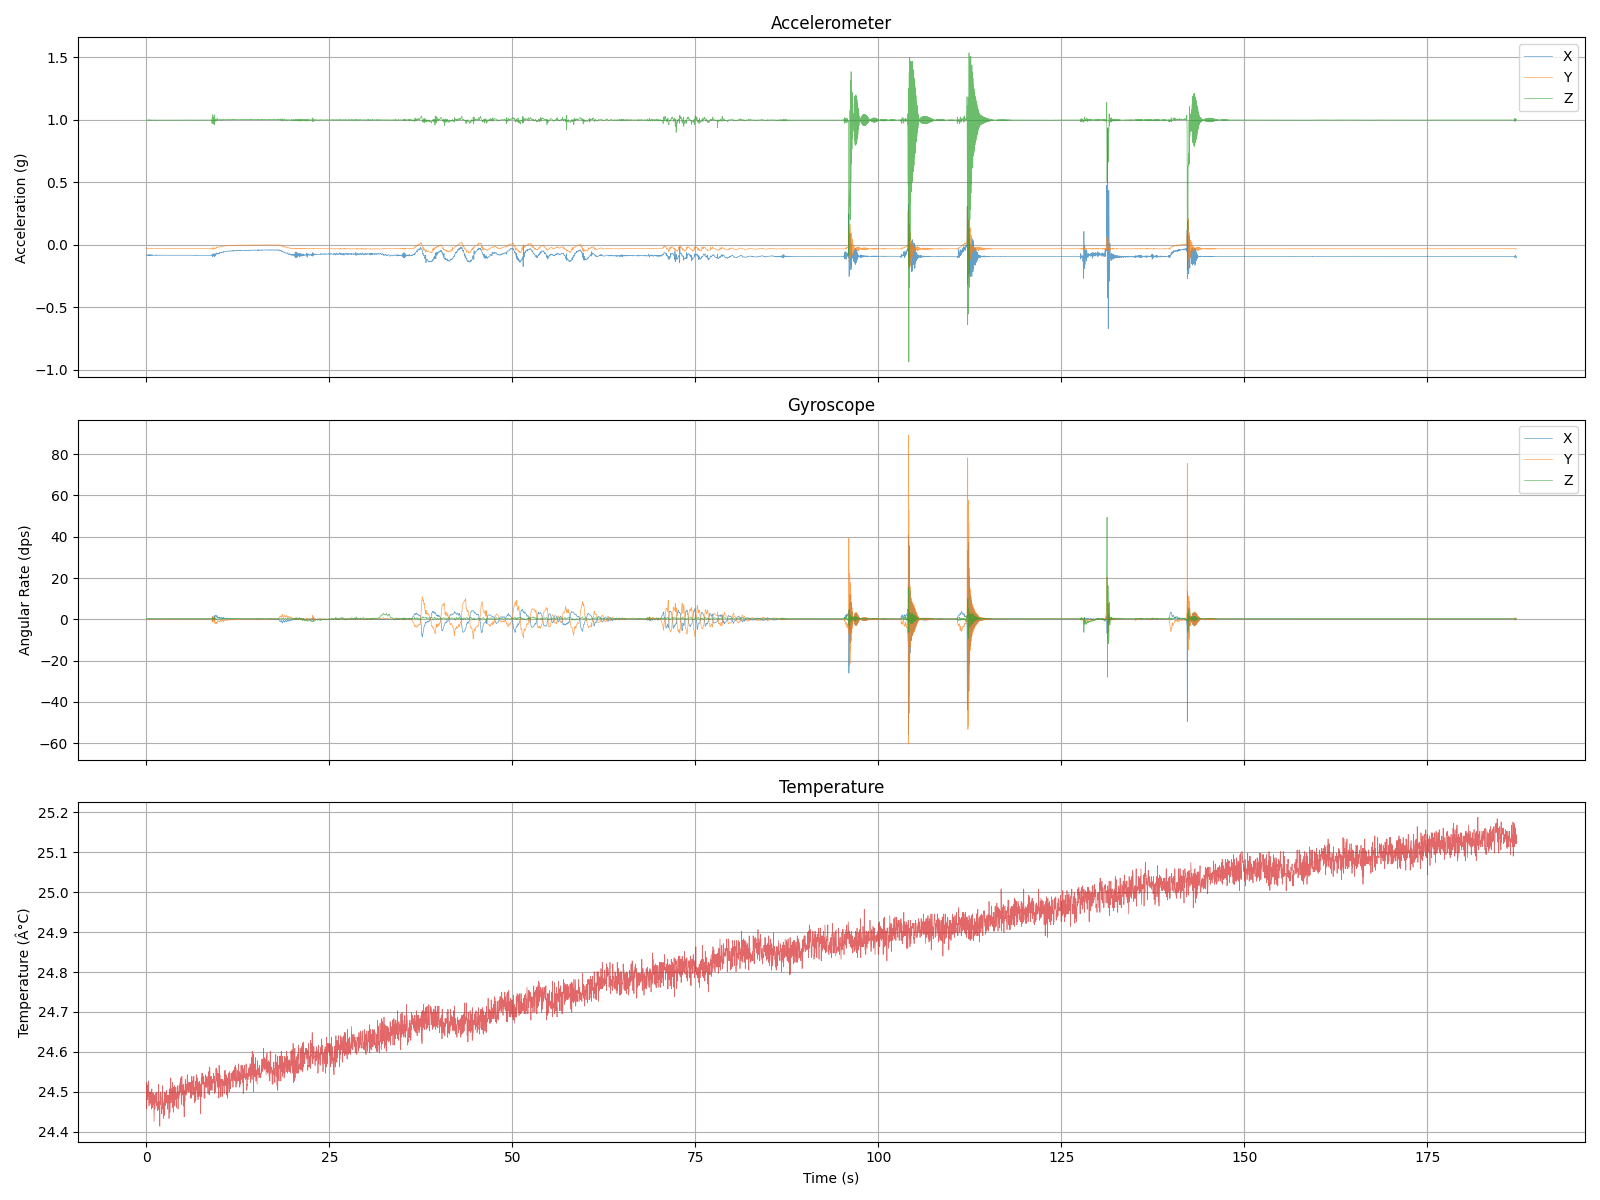

In [5]:
%matplotlib ipympl
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(16, 12))

axes[0].plot(df['timestamp_s'], df['accel_x'], alpha=0.7, linewidth=0.5, label='X')
axes[0].plot(df['timestamp_s'], df['accel_y'], alpha=0.7, linewidth=0.5, label='Y')
axes[0].plot(df['timestamp_s'], df['accel_z'], alpha=0.7, linewidth=0.5, label='Z')
axes[0].set_ylabel('Acceleration (g)')
axes[0].set_title('Accelerometer')
axes[0].legend(loc='upper right')

axes[1].plot(df['timestamp_s'], df['gyro_x'], alpha=0.7, linewidth=0.5, label='X')
axes[1].plot(df['timestamp_s'], df['gyro_y'], alpha=0.7, linewidth=0.5, label='Y')
axes[1].plot(df['timestamp_s'], df['gyro_z'], alpha=0.7, linewidth=0.5, label='Z')
axes[1].set_ylabel('Angular Rate (dps)')
axes[1].set_title('Gyroscope')
axes[1].legend(loc='upper right')

axes[2].plot(df['timestamp_s'], df['temp_c'], color='tab:red', alpha=0.7, linewidth=0.5)
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Temperature (Â°C)')
axes[2].set_title('Temperature')

fig.tight_layout()
plt.show()

In [6]:
ALPHA = 0.98

df = apply_complementary_filter(df, alpha=ALPHA)

df[['timestamp_s', 'pitch_deg', 'roll_deg']].head()

,timestamp_s,pitch_deg,roll_deg
0,0.000000,-0.096045,0.036068
1,0.029747,-0.189485,0.074839
2,0.059918,-0.280318,0.112661
3,0.089769,-0.369340,0.149695
4,0.119833,-0.457899,0.185946


In [7]:
ALPHA_BASE = 0.98
K_GAIN = 47.5
KP_MAHONY = 0.5
KI_MAHONY = 0.1
K_MAHONY_GAIN = 47.5

df = apply_adaptive_complementary_filter(df, alpha_base=ALPHA_BASE, k_gain=K_GAIN)
df = apply_mahony_filter(df, Kp=KP_MAHONY, Ki=KI_MAHONY, k_gain=K_MAHONY_GAIN)

df[['timestamp_s', 'roll_deg', 'roll_adapt', 'roll_mahony',
    'pitch_deg', 'pitch_adapt', 'pitch_mahony']].head()


,timestamp_s,roll_deg,roll_adapt,roll_mahony,pitch_deg,pitch_adapt,pitch_mahony
0,0.000000,0.036068,0.033798,0.000000,-0.096045,-0.089999,0.000000
1,0.029747,0.074839,0.069409,-0.021273,-0.189485,-0.175060,0.065848
2,0.059918,0.112661,0.105861,-0.044285,-0.280318,-0.262285,0.135028
3,0.089769,0.149695,0.141582,-0.066864,-0.369340,-0.347845,0.202886
4,0.119833,0.185946,0.174836,-0.087534,-0.457899,-0.428222,0.268780


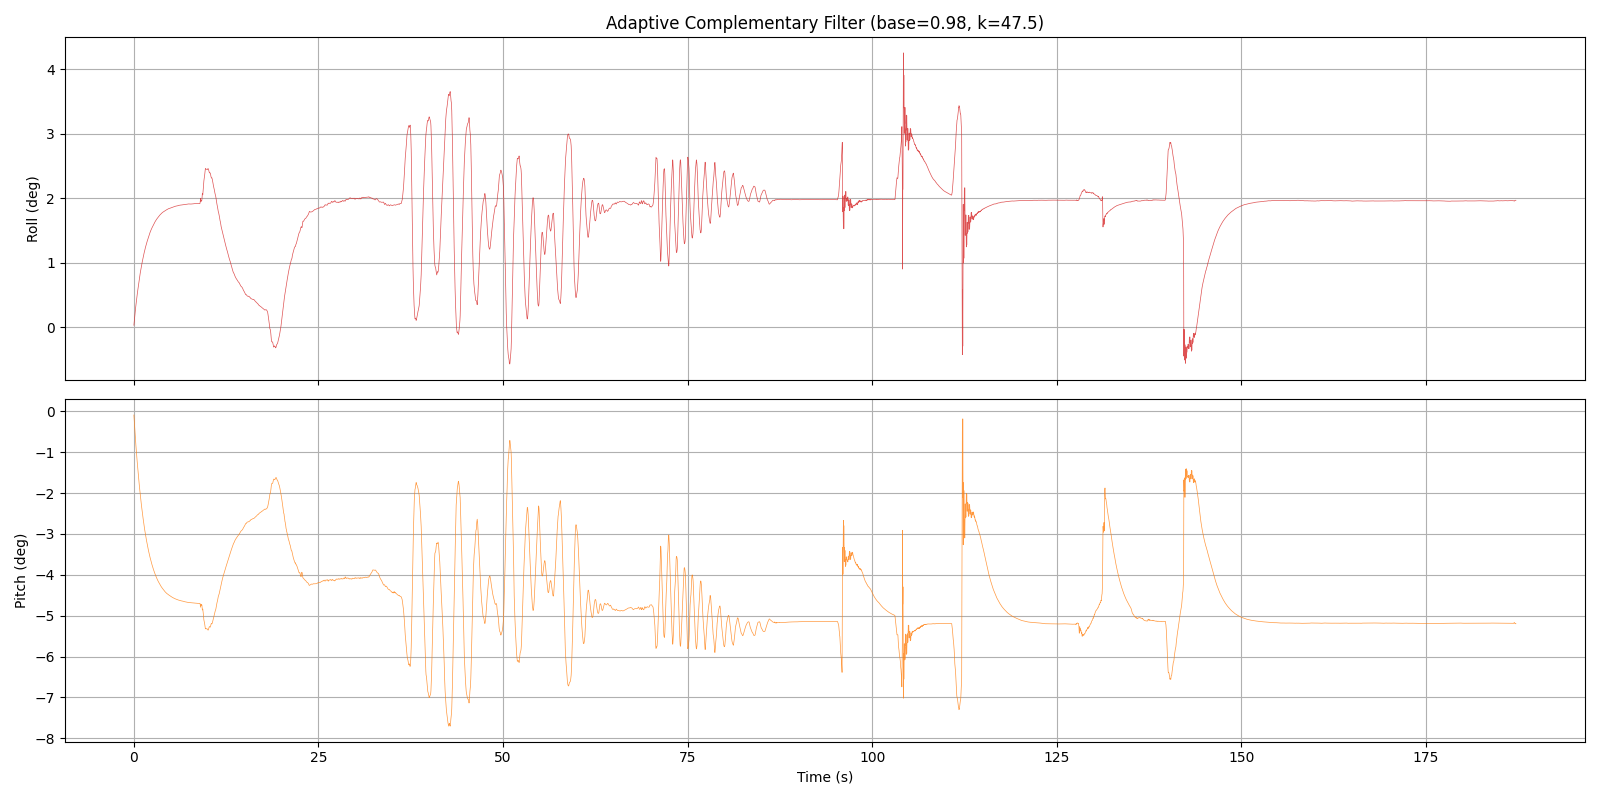

In [8]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(16, 8))

axes[0].plot(df['timestamp_s'], df['roll_adapt'], color='tab:red', linewidth=0.5, alpha=0.8)
axes[0].set_ylabel('Roll (deg)')
axes[0].set_title(f'Adaptive Complementary Filter (base={ALPHA_BASE}, k={K_GAIN})')

axes[1].plot(df['timestamp_s'], df['pitch_adapt'], color='tab:orange', linewidth=0.5, alpha=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Pitch (deg)')

fig.tight_layout()
plt.show()


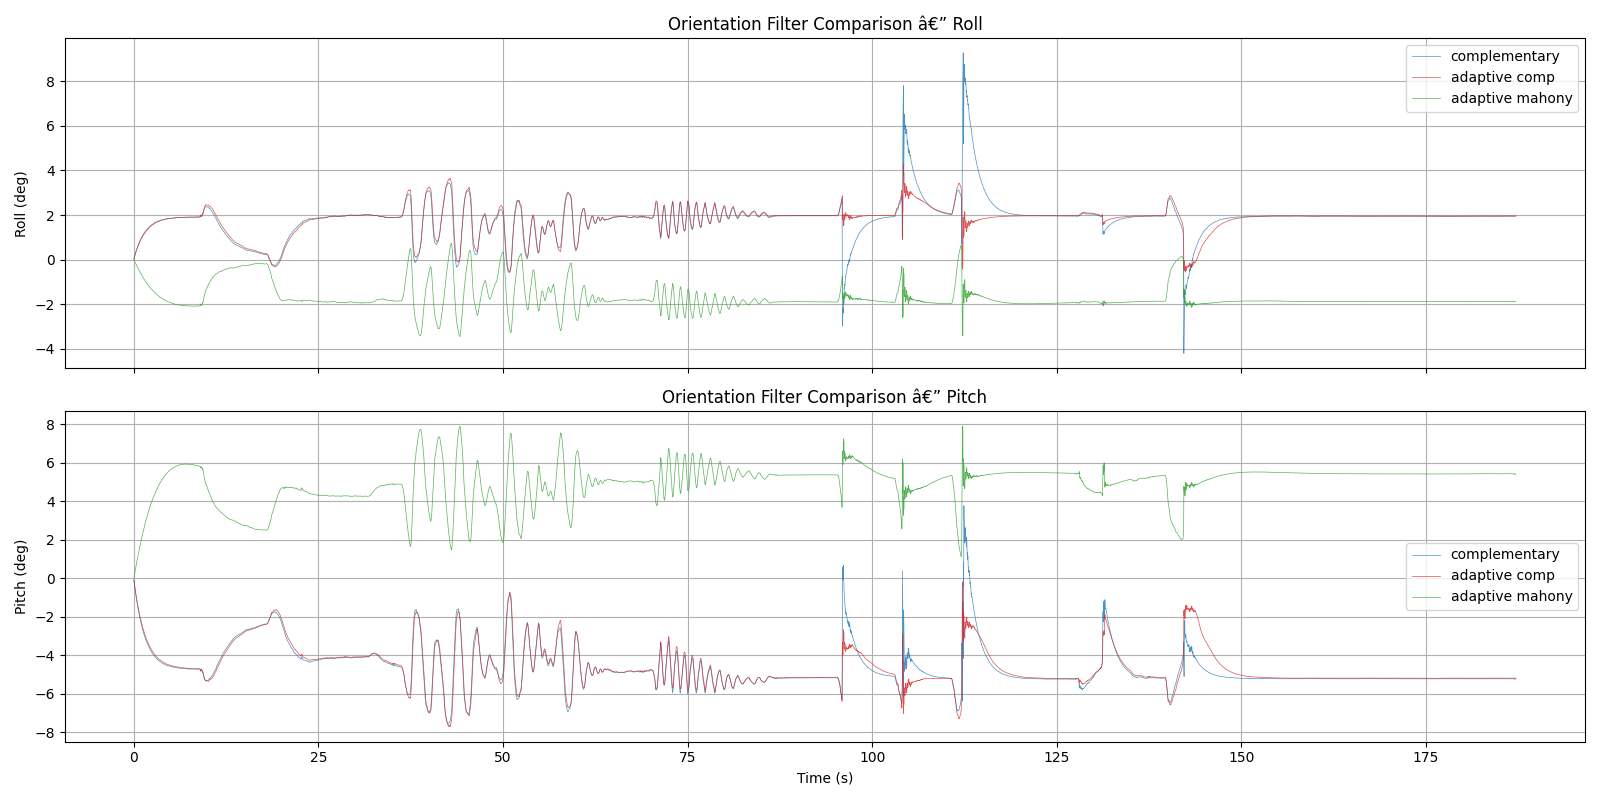

In [9]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(16, 8))

axes[0].plot(df['timestamp_s'], df['roll_deg'], color='tab:blue', linewidth=0.5, alpha=0.8, label='complementary')
axes[0].plot(df['timestamp_s'], df['roll_adapt'], color='tab:red', linewidth=0.5, alpha=0.8, label='adaptive comp')
axes[0].plot(df['timestamp_s'], df['roll_mahony'], color='tab:green', linewidth=0.5, alpha=0.8, label='adaptive mahony')
axes[0].set_ylabel('Roll (deg)')
axes[0].set_title('Orientation Filter Comparison â€” Roll')
axes[0].legend()

axes[1].plot(df['timestamp_s'], df['pitch_deg'], color='tab:blue', linewidth=0.5, alpha=0.8, label='complementary')
axes[1].plot(df['timestamp_s'], df['pitch_adapt'], color='tab:red', linewidth=0.5, alpha=0.8, label='adaptive comp')
axes[1].plot(df['timestamp_s'], df['pitch_mahony'], color='tab:green', linewidth=0.5, alpha=0.8, label='adaptive mahony')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Pitch (deg)')
axes[1].set_title('Orientation Filter Comparison â€” Pitch')
axes[1].legend()

fig.tight_layout()
plt.show()

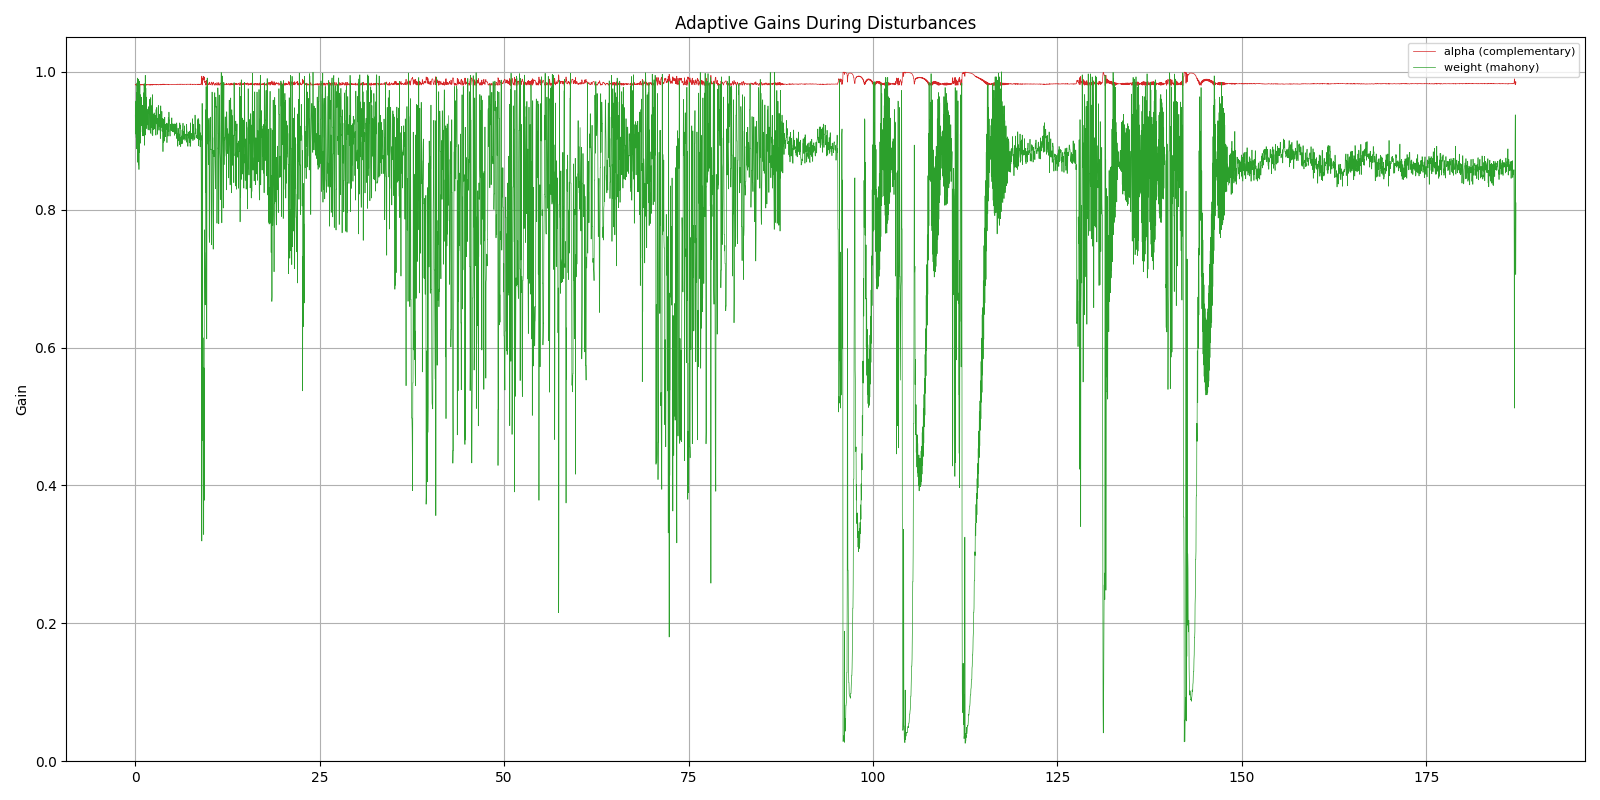

In [10]:
fig, ax1 = plt.subplots(1, 1, sharex=True, figsize=(16, 8))

ax1.plot(df['timestamp_s'], df['alpha_adapt'], color='tab:red', linewidth=0.5, label='alpha (complementary)')
ax1.plot(df['timestamp_s'], df['mahony_weight'], color='tab:green', linewidth=0.5, label='weight (mahony)')
ax1.set_ylabel('Gain')
ax1.set_title('Adaptive Gains During Disturbances')
ax1.set_ylim(0.0, 1.05)
ax1.legend(fontsize=8)

fig.tight_layout()
plt.show()


In [11]:
SETTLE_SAMPLES = 500
TARE_SAMPLES = 100

roll_offset, pitch_offset, tare_start, tare_end = compute_tare_offsets(
    df, settle_samples=SETTLE_SAMPLES, tare_samples=TARE_SAMPLES,
    roll_col='roll_adapt', pitch_col='pitch_adapt'
)
print(f'Tare window: [{tare_start}, {tare_end})')
print(f'Roll offset:  {roll_offset:.4f} deg')
print(f'Pitch offset: {pitch_offset:.4f} deg')

Tare window: [500, 600)
Roll offset:  0.3929 deg
Pitch offset: -2.5712 deg


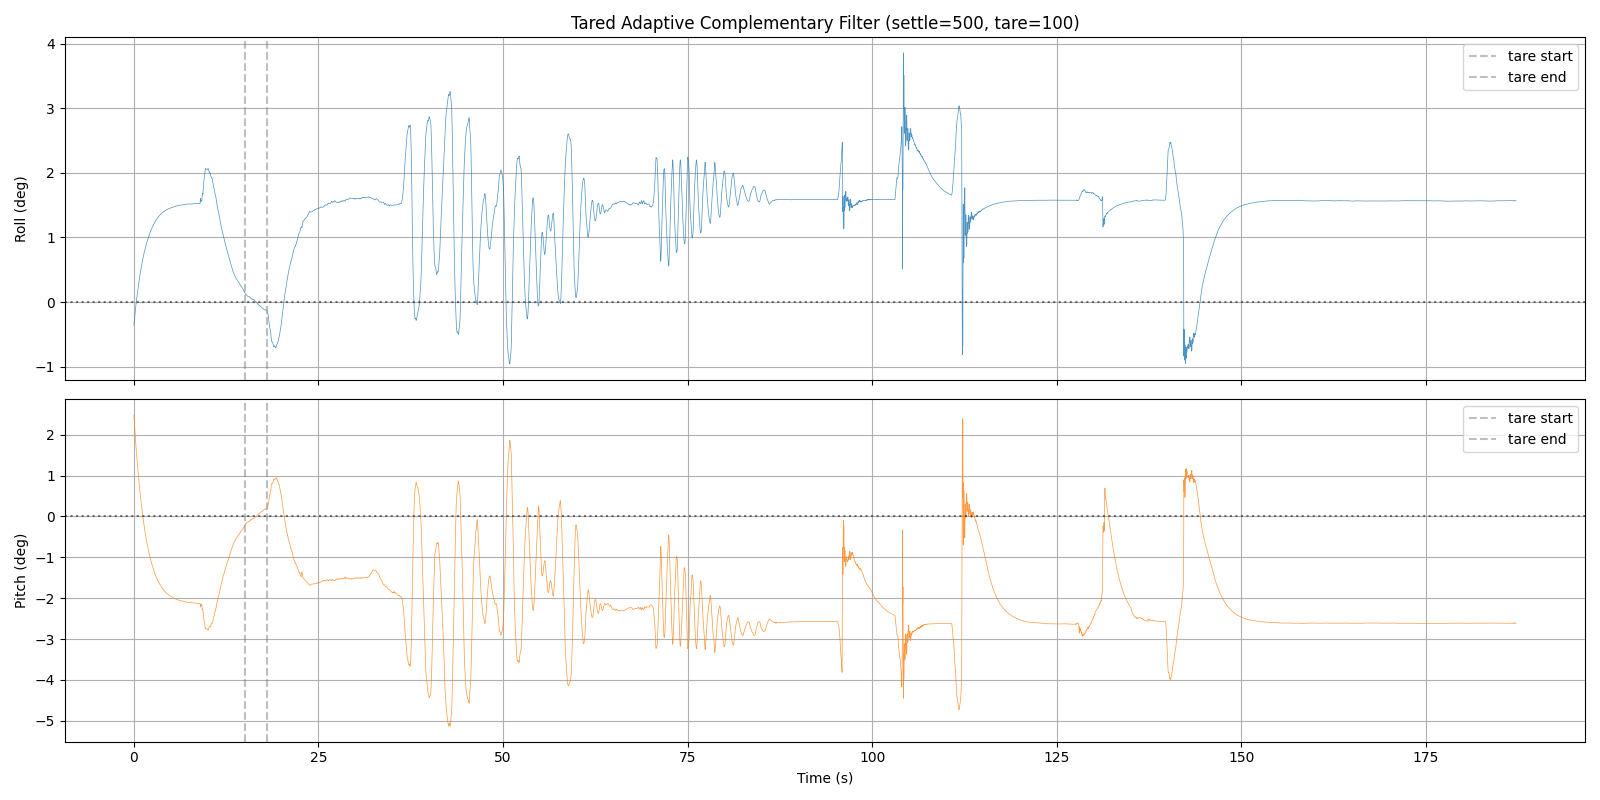

In [12]:
df, roll_offset, pitch_offset, tare_start, tare_end = apply_taring(
    df, settle_samples=SETTLE_SAMPLES, tare_samples=TARE_SAMPLES,
    roll_col='roll_adapt', pitch_col='pitch_adapt'
)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(16, 8))

axes[0].plot(df['timestamp_s'], df['roll_tared'], color='tab:blue', linewidth=0.5, alpha=0.8)
axes[0].axvline(df['timestamp_s'].iloc[tare_start], color='gray', linestyle='--', alpha=0.5, label='tare start')
axes[0].axvline(df['timestamp_s'].iloc[tare_end], color='gray', linestyle='--', alpha=0.5, label='tare end')
axes[0].axhline(0, color='black', linestyle=':', alpha=0.5)
axes[0].set_ylabel('Roll (deg)')
axes[0].set_title(f'Tared Adaptive Complementary Filter (settle={SETTLE_SAMPLES}, tare={TARE_SAMPLES})')
axes[0].legend()

axes[1].plot(df['timestamp_s'], df['pitch_tared'], color='tab:orange', linewidth=0.5, alpha=0.8)
axes[1].axvline(df['timestamp_s'].iloc[tare_start], color='gray', linestyle='--', alpha=0.5, label='tare start')
axes[1].axvline(df['timestamp_s'].iloc[tare_end], color='gray', linestyle='--', alpha=0.5, label='tare end')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Pitch (deg)')
axes[1].legend()

fig.tight_layout()
plt.show()

In [13]:
HP_CUTOFF_HZ = 0.2
HP_THRESHOLD_G = 0.024
HP_ORDER = 2
HP_RIPPLE_DB = 1.0
DEBOUNCE = 72
HPF_SETTLE = SETTLE_SAMPLES + TARE_SAMPLES

state, hpf_x, hpf_y, hpf_z, hpf_mag, hp_threshold, hp_fs = detect_disturbed(
    df,
    hp_cutoff_hz=HP_CUTOFF_HZ,
    hp_threshold_g=HP_THRESHOLD_G,
    hp_order=HP_ORDER,
    hp_ripple_db=HP_RIPPLE_DB,
    debounce=DEBOUNCE,
    settle_samples=HPF_SETTLE,
)

df['state'] = state
df['hpf_x'] = hpf_x
df['hpf_y'] = hpf_y
df['hpf_z'] = hpf_z
df['hpf_mag'] = hpf_mag

disturbed_mask = df['state'] == 1
disturbed_pct = 100.0 * disturbed_mask.sum() / len(df)

print(f'HPF: Chebyshev Type 1, order={HP_ORDER}, fc={HP_CUTOFF_HZ} Hz, ripple={HP_RIPPLE_DB} dB')
print(f'Design fs: {hp_fs:.1f} Hz')
print(f'HPF threshold:   {HP_THRESHOLD_G} g')
print(f'Debounce:        {DEBOUNCE} samples')
print(f'Disturbed:       {disturbed_pct:.1f}% ({disturbed_mask.sum()} samples)')

transitions = np.diff(state.astype(np.int8))
enter_idx = np.where(transitions == 1)[0] + 1
exit_idx = np.where(transitions == -1)[0] + 1
if len(enter_idx) > 0:
    print(f'\nDisturbance events: {len(enter_idx)}')
    for j, (e, x) in enumerate(zip(enter_idx, exit_idx if len(exit_idx) >= len(enter_idx) else np.concatenate([exit_idx, [len(df)-1]]))):
        print(f'  {j+1}: t={df["timestamp_s"].iloc[e]:.2f}s -> t={df["timestamp_s"].iloc[min(x, len(df)-1)]:.2f}s (dur {df["timestamp_s"].iloc[min(x, len(df)-1)] - df["timestamp_s"].iloc[e]:.2f}s)')

HPF: Chebyshev Type 1, order=2, fc=0.2 Hz, ripple=1.0 dB
Design fs: 33.3 Hz
HPF threshold:   0.024 g
Debounce:        72 samples
Disturbed:       41.4% (2584 samples)

Disturbance events: 10
  1: t=20.40s -> t=22.65s (dur 2.25s)
  2: t=36.90s -> t=63.00s (dur 26.10s)
  3: t=70.59s -> t=80.85s (dur 10.26s)
  4: t=95.34s -> t=102.06s (dur 6.72s)
  5: t=103.20s -> t=110.37s (dur 7.17s)
  6: t=110.79s -> t=118.41s (dur 7.62s)
  7: t=127.62s -> t=130.86s (dur 3.24s)
  8: t=131.07s -> t=134.94s (dur 3.87s)
  9: t=137.40s -> t=139.56s (dur 2.16s)
  10: t=139.98s -> t=148.11s (dur 8.13s)


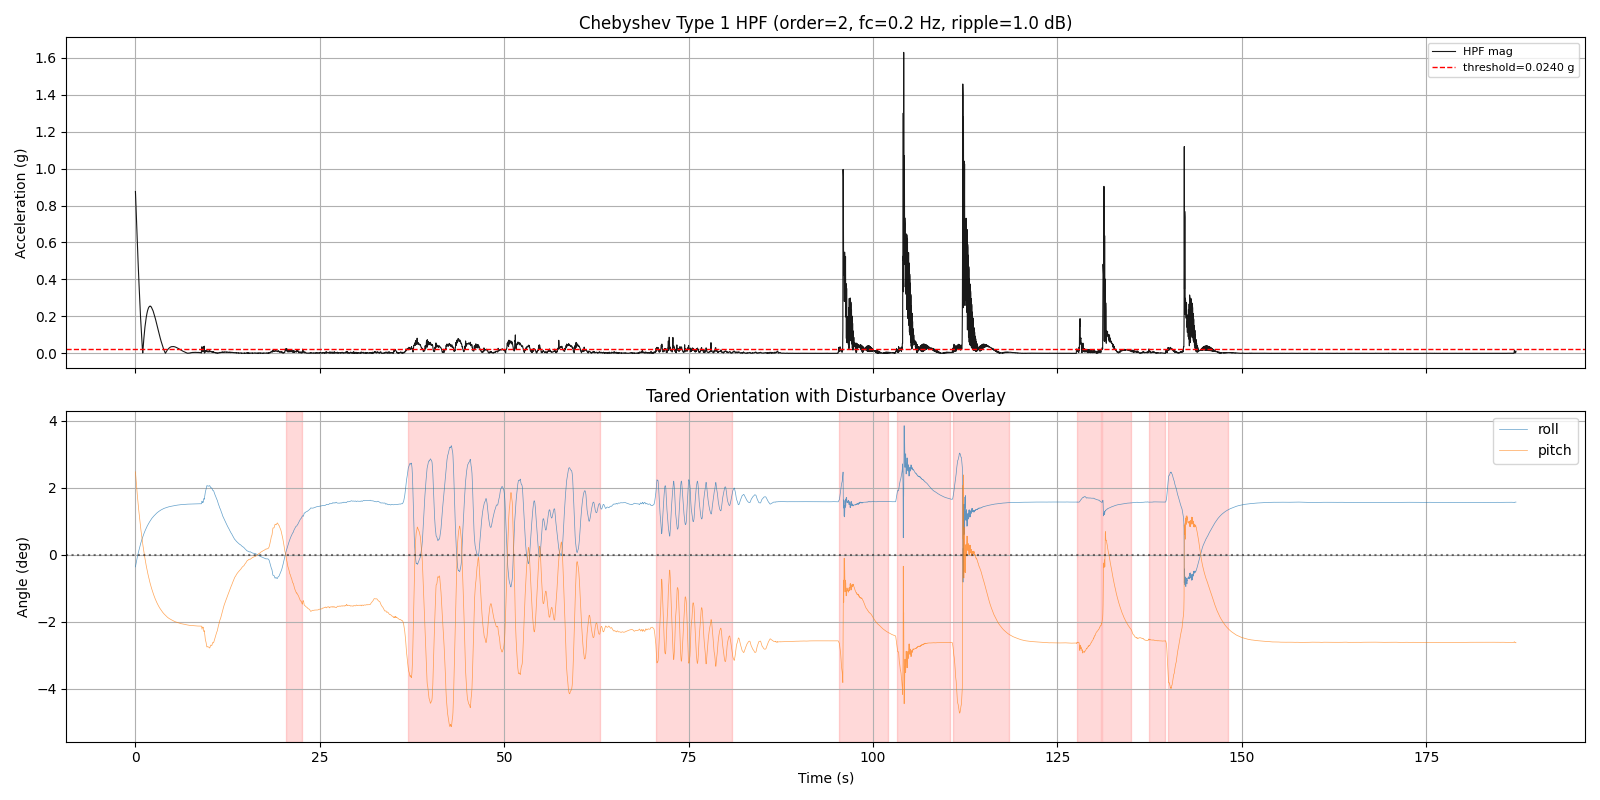

In [14]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(16, 8))

axes[0].plot(df['timestamp_s'], df['hpf_mag'], linewidth=0.8, color='black', alpha=0.9, label='HPF mag')
axes[0].axhline(hp_threshold, color='red', linestyle='--', linewidth=1, label=f'threshold={hp_threshold:.4f} g')
axes[0].set_ylabel('Acceleration (g)')
axes[0].set_title(f'Chebyshev Type 1 HPF (order={HP_ORDER}, fc={HP_CUTOFF_HZ} Hz, ripple={HP_RIPPLE_DB} dB)')
axes[0].legend(loc='upper right', fontsize=8)

axes[1].plot(df['timestamp_s'], df['roll_tared'], color='tab:blue', linewidth=0.5, alpha=0.7, label='roll')
axes[1].plot(df['timestamp_s'], df['pitch_tared'], color='tab:orange', linewidth=0.5, alpha=0.7, label='pitch')
for e, x in zip(enter_idx, exit_idx if len(exit_idx) >= len(enter_idx) else np.concatenate([exit_idx, [len(df)-1]])):
    axes[1].axvspan(df['timestamp_s'].iloc[e], df['timestamp_s'].iloc[min(x, len(df)-1)],
                    alpha=0.15, color='red')
axes[1].axhline(0, color='black', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (deg)')
axes[1].set_title('Tared Orientation with Disturbance Overlay')
axes[1].legend(loc='upper right')

fig.tight_layout()
plt.show()

In [15]:
SAMPLE_RATE_HZ = hp_fs
FREQ_MIN_HZ = 0.5
FREQ_MAX_HZ = 12.0
CENTERLINE_MIN_AMP_DEG = 0.05
BASELINE_MODE = 'centerline'

events = compute_disturbance_metrics(
    df, disturbed_mask, SAMPLE_RATE_HZ,
    freq_min_hz=FREQ_MIN_HZ,
    freq_max_hz=FREQ_MAX_HZ,
    centerline_min_amp=CENTERLINE_MIN_AMP_DEG,
    baseline_mode=BASELINE_MODE,
)

print(f'Disturbance events: {len(events)}')
print(f'Modal FFT search: {FREQ_MIN_HZ:.1f}-{FREQ_MAX_HZ:.1f} Hz, baseline_mode={BASELINE_MODE}, centerline_min_amp={CENTERLINE_MIN_AMP_DEG:.2f} deg')
hdr = f'{"#":>3}  {"dur":>5}  {"f_p":>6}  {"f_p_old":>7}  {"z_p":>7}  {"z_p_old":>8}  {"amp_n":>5}  {"sw_p":>6}'
print(hdr)
print('-' * len(hdr))
for ev in events:
    amp_n = len(ev['pitch_decay_amplitudes'])
    print(f'{ev["index"]:>3}  {ev["duration_s"]:>4.1f}s  {ev["freq_pitch_hz"]:>6.2f}  {ev["legacy_freq_pitch_hz"]:>7.2f}  {ev["zeta_pitch"]:>7.4f}  {ev["legacy_zeta_pitch"]:>8.4f}  {amp_n:>5}  {ev["sway_pitch_pp_max"]:>6.2f}')

print()
print('Per-axis extrema/pair/amplitude counts:')
for ev in events:
    n_raw_r = len(ev['roll_extrema'])
    n_col_r = len(ev['roll_collapsed_extrema'])
    n_pairs_r = len(ev['roll_centerline_pairs'])
    n_amp_r = len(ev['roll_decay_amplitudes'])
    n_raw_p = len(ev['pitch_extrema'])
    n_col_p = len(ev['pitch_collapsed_extrema'])
    n_pairs_p = len(ev['pitch_centerline_pairs'])
    n_amp_p = len(ev['pitch_decay_amplitudes'])
    print(f'#{ev["index"]:>3} roll:  raw={n_raw_r:>3} col={n_col_r:>3} pairs={n_pairs_r:>2} amp_n={n_amp_r:>2}')
    print(f'     pitch: raw={n_raw_p:>3} col={n_col_p:>3} pairs={n_pairs_p:>2} amp_n={n_amp_p:>2}')

Disturbance events: 10
Modal FFT search: 0.5-12.0 Hz, baseline_mode=centerline, centerline_min_amp=0.05 deg
  #    dur     f_p  f_p_old      z_p   z_p_old  amp_n    sw_p
-------------------------------------------------------------
  0   2.3s    0.52     0.52   0.0000    0.0000      0    0.21
  1  26.1s    0.59     0.59   0.0254    0.0000     24    5.99
  2  10.3s    0.91     0.91   0.0233    0.0000     14    2.67
  3   6.7s    0.85     0.85   0.1951    0.0000      8    3.06
  4   7.2s    0.72     2.41   0.0972    0.0000      6    3.83
  5   7.6s    0.52     0.52   0.6325    0.0000      8    6.81
  6   3.2s    0.52     0.52   0.0000    0.0000      1    0.24
  7   3.9s    0.52     0.52   0.0000    0.0000      2    1.05
  8   2.2s    0.52     0.52   0.0000    0.0000      0    0.02
  9   8.1s    0.72     0.65   0.3744    0.0000      5    4.88

Per-axis extrema/pair/amplitude counts:
#  0 roll:  raw=  1 col=  1 pairs= 0 amp_n= 0
     pitch: raw=  4 col=  1 pairs= 0 amp_n= 0
#  1 roll:  raw

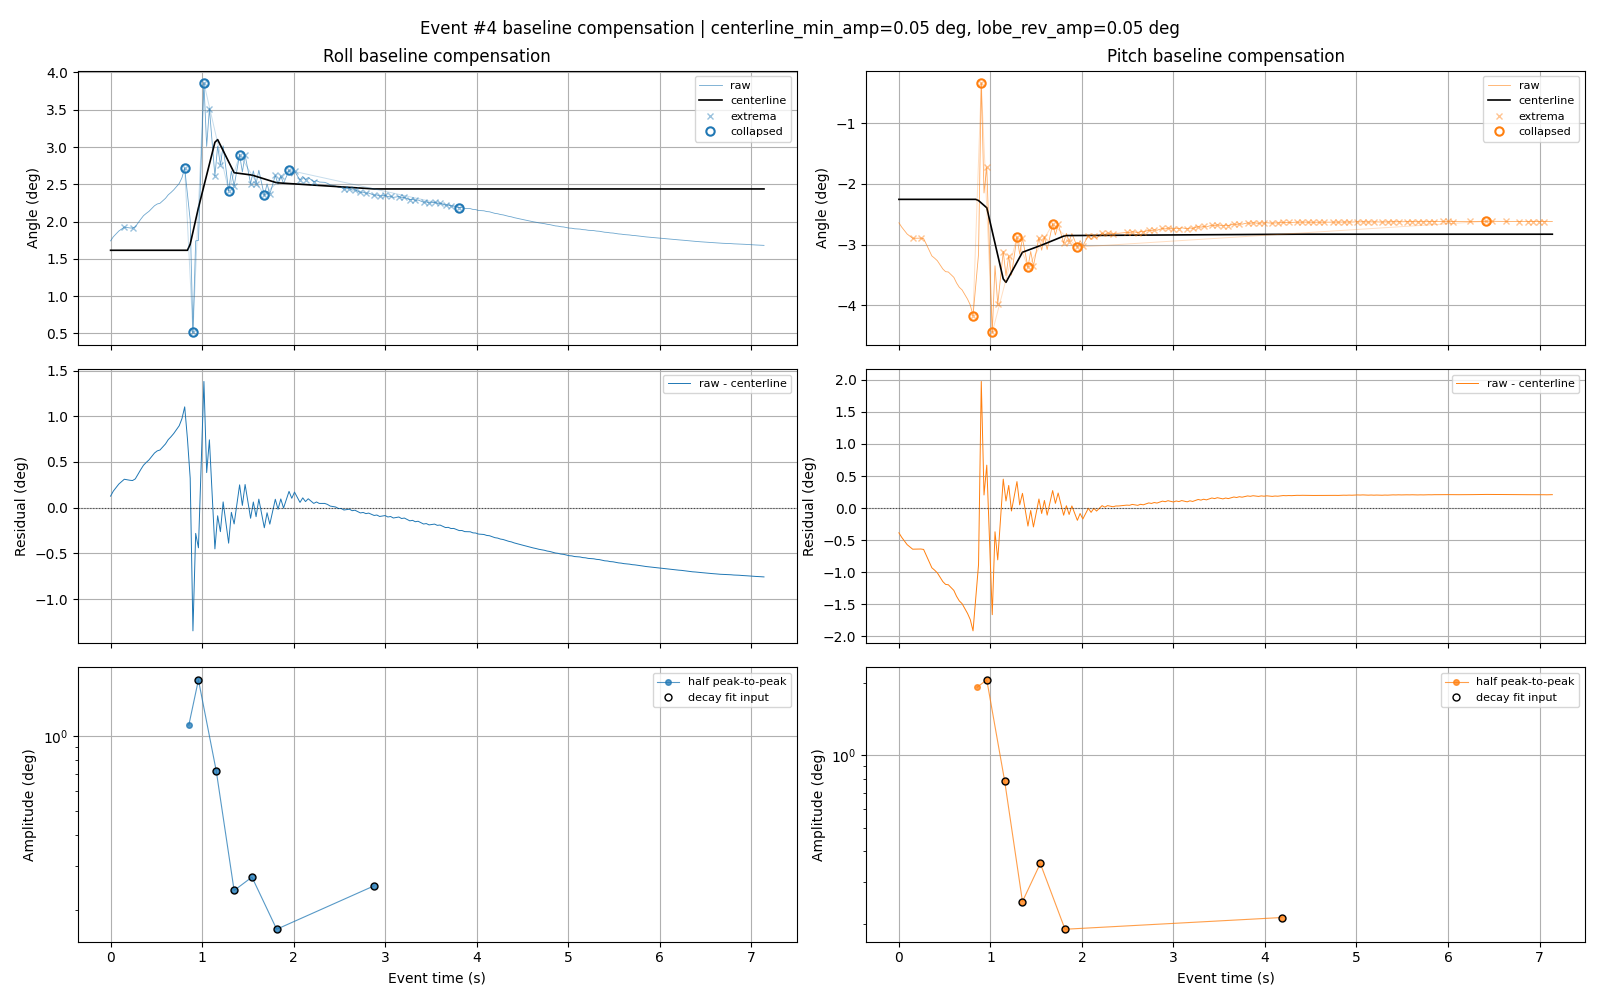

In [21]:
BASELINE_EVENT_IDX = 4

if events:
    ev = events[min(BASELINE_EVENT_IDX, len(events) - 1)]
    t = df['timestamp_s'].iloc[ev['start']:ev['end']].to_numpy(dtype=np.float64)
    t_rel = t - ev['t_start']

    fig, axes = plt.subplots(3, 2, sharex='col', figsize=(16, 10))

    for col, axis_key, color in [
        (0, 'roll', 'tab:blue'),
        (1, 'pitch', 'tab:orange'),
    ]:
        raw = df[f'{axis_key}_tared'].iloc[ev['start']:ev['end']].to_numpy(dtype=np.float64)
        centerline = ev[f'{axis_key}_centerline']
        residual = ev[f'{axis_key}_residual']
        extrema = ev[f'{axis_key}_extrema']
        collapsed_extrema = ev[f'{axis_key}_collapsed_extrema']
        pairs = ev[f'{axis_key}_centerline_pairs']
        decay = ev[f'{axis_key}_decay_amplitudes']

        ax = axes[0, col]
        ax.plot(t_rel, raw, color=color, linewidth=0.6, alpha=0.65, label='raw')
        ax.plot(t_rel, centerline, color='black', linewidth=1.2, label='centerline')
        if extrema:
            ext_idx = np.array([p['idx'] for p in extrema], dtype=np.int32)
            ext_val = np.array([p['value'] for p in extrema], dtype=np.float64)
            ax.plot(t_rel[ext_idx], ext_val, 'x', color=color, ms=4, alpha=0.45, label='extrema')
        if collapsed_extrema:
            c_ext_idx = np.array([p['idx'] for p in collapsed_extrema], dtype=np.int32)
            c_ext_val = np.array([p['value'] for p in collapsed_extrema], dtype=np.float64)
            ax.plot(t_rel[c_ext_idx], c_ext_val, 'o', color=color, ms=6, mfc='none', mew=1.5, label='collapsed')
        for pair in pairs:
            l_idx = pair['left_idx']
            r_idx = pair['right_idx']
            ax.plot([t_rel[l_idx], t_rel[r_idx]],
                    [pair['left_value'], pair['right_value']],
                    color=color, linewidth=0.7, alpha=0.25)
        ax.set_ylabel('Angle (deg)')
        ax.set_title(f'{axis_key.title()} baseline compensation')
        ax.legend(fontsize=8)

        ax = axes[1, col]
        ax.plot(t_rel, residual, color=color, linewidth=0.7, label='raw - centerline')
        ax.axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.6)
        ax.set_ylabel('Residual (deg)')
        ax.legend(fontsize=8)

        ax = axes[2, col]
        if pairs:
            pair_t = np.array([p['time'] for p in pairs], dtype=np.float64)
            pair_amp = np.array([p['amplitude'] for p in pairs], dtype=np.float64)
            ax.semilogy(pair_t, pair_amp, 'o-', color=color, ms=4, linewidth=0.8,
                        alpha=0.75, label='half peak-to-peak')
        if decay:
            decay_t = np.array([p[0] for p in decay], dtype=np.float64)
            decay_amp = np.array([p[1] for p in decay], dtype=np.float64)
            ax.semilogy(decay_t, decay_amp, 'o', color='black', ms=5,
                        mfc='none', label='decay fit input')
        ax.set_xlabel('Event time (s)')
        ax.set_ylabel('Amplitude (deg)')
        ax.legend(fontsize=8)

    fig.suptitle(f'Event #{ev["index"]} baseline compensation | '
                 f'centerline_min_amp={ev["centerline_min_amp_deg"]:.2f} deg, lobe_rev_amp={ev["lobe_reversal_min_amp_deg"]:.2f} deg')
    fig.tight_layout()
    plt.show()


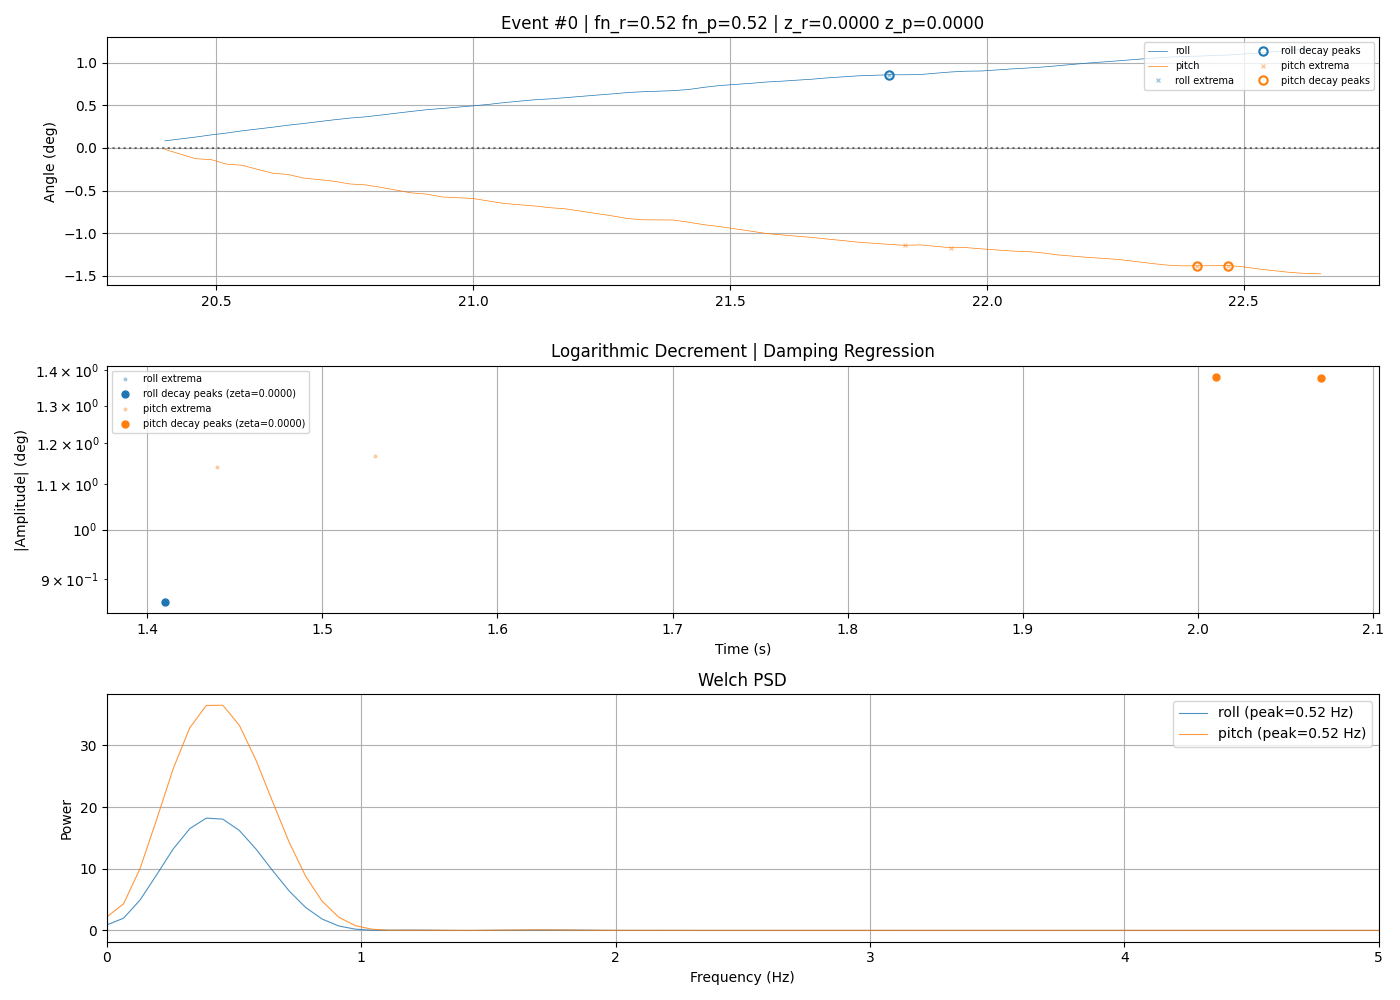

In [17]:
EVENT_IDX = 0

if events:
    ev = events[min(EVENT_IDX, len(events) - 1)]

    t_start = ev['t_start']
    t_end = ev['t_end']
    mask = (df['timestamp_s'] >= t_start) & (df['timestamp_s'] <= t_end)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # --- Top: time-domain with peak detection and envelope ---
    ax = axes[0]
    ax.plot(df['timestamp_s'][mask], df['roll_tared'][mask], color='tab:blue', linewidth=0.5, label='roll')
    ax.plot(df['timestamp_s'][mask], df['pitch_tared'][mask], color='tab:orange', linewidth=0.5, label='pitch')

    for axis_key, color, peaks, all_t, all_a, all_s in [
        ('roll', 'tab:blue', ev['r_peaks'], ev['r_all_times'], ev['r_all_amps'], ev['r_signs']),
        ('pitch', 'tab:orange', ev['p_peaks'], ev['p_all_times'], ev['p_all_amps'], ev['p_signs']),
    ]:
        if all_t:
            ext_t = np.array(all_t) + t_start
            ext_v = np.array(all_a) * np.array(all_s)
            ax.plot(ext_t, ext_v, 'x', color=color, ms=3, alpha=0.4, label=f'{axis_key} extrema')
        if peaks:
            pk_t = np.array([p[0] for p in peaks]) + t_start
            pk_a = np.array([p[1] for p in peaks])
            ak_signs = [all_s[i] for i, p in enumerate(all_t) if p in [pp[0] for pp in peaks]]
            pk_v = pk_a * np.array(ak_signs)
            ax.plot(pk_t, pk_v, 'o', color=color, ms=6, mfc='none', mew=1.5,
                    label=f'{axis_key} decay peaks')
            if len(pk_t) >= 4:
                from scipy.interpolate import make_interp_spline
                try:
                    spl = make_interp_spline(pk_t, pk_a, k=min(3, len(pk_t)-1))
                    t_env = np.linspace(pk_t[0], pk_t[-1], 200)
                    ax.fill_between(t_env, spl(t_env), -spl(t_env), color=color, alpha=0.08)
                    ax.plot(t_env, spl(t_env), '--', color=color, linewidth=0.8, alpha=0.6)
                    ax.plot(t_env, -spl(t_env), '--', color=color, linewidth=0.8, alpha=0.6)
                except Exception:
                    pass

    ax.axhline(0, color='black', linestyle=':', alpha=0.5)
    ax.set_ylabel('Angle (deg)')
    ax.set_title(f'Event #{ev["index"]} | fn_r={ev["freq_roll_hz"]:.2f} fn_p={ev["freq_pitch_hz"]:.2f} | '
                 f'z_r={ev["zeta_roll"]:.4f} z_p={ev["zeta_pitch"]:.4f}')
    ax.legend(loc='upper right', fontsize=7, ncol=2)

    # --- Middle: semilogy with log-decay fit ---
    ax = axes[1]
    for axis_key, color, zeta, peaks, all_t, all_a in [
        ('roll', 'tab:blue', ev['zeta_roll'], ev['r_peaks'], ev['r_all_times'], ev['r_all_amps']),
        ('pitch', 'tab:orange', ev['zeta_pitch'], ev['p_peaks'], ev['p_all_times'], ev['p_all_amps']),
    ]:
        ax.semilogy(all_t, all_a, 'o', color=color, ms=2, alpha=0.3, label=f'{axis_key} extrema')
        if peaks:
            t_vals = [p[0] for p in peaks]
            a_vals = [p[1] for p in peaks]
            ax.semilogy(t_vals, a_vals, 'o', color=color, ms=5, label=f'{axis_key} decay peaks (zeta={zeta:.4f})')
            if len(t_vals) >= 4:
                n = len(t_vals)
                sum_t = sum(t_vals)
                sum_y = sum(math.log(a) for a in a_vals)
                sum_ty = sum(t_vals[i] * math.log(a_vals[i]) for i in range(n))
                sum_t2 = sum(t * t for t in t_vals)
                denom = n * sum_t2 - sum_t * sum_t
                if denom > 0:
                    slope = (n * sum_ty - sum_t * sum_y) / denom
                    intercept = (sum_y - slope * sum_t) / n
                    t_fit = np.linspace(t_vals[0], t_vals[-1], 100)
                    ax.plot(t_fit, np.exp(slope * np.array(t_fit) + intercept), '--', color=color, linewidth=1, alpha=0.8,
                            label=f'{axis_key} fit (slope={slope:.3f})')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('|Amplitude| (deg)')
    ax.set_title('Logarithmic Decrement | Damping Regression')
    ax.legend(fontsize=7)

    # --- Bottom: Welch PSD ---
    ax = axes[2]
    if ev['freqs_r'] is not None:
        ax.plot(ev['freqs_r'], ev['psd_r'], color='tab:blue', linewidth=0.8, alpha=0.8, label=f'roll (peak={ev["freq_roll_hz"]:.2f} Hz)')
        ax.plot(ev['freqs_p'], ev['psd_p'], color='tab:orange', linewidth=0.8, alpha=0.8, label=f'pitch (peak={ev["freq_pitch_hz"]:.2f} Hz)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.set_title('Welch PSD')
    ax.legend()
    ax.set_xlim(0, 5)

    fig.tight_layout()
    plt.show()